# *따릉이 대여 데이터 — 기초 EDA 리포트*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


## 1. 데이터 개요
- 행/열: 181행, 5열
- 기간: 2025-01-01 ~ 2025-06-29
- 주요 컬럼: date, rentals, avg_temp, rainfall, station_area


In [5]:
%pip install numpy pandas matplotlib seaborn

   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.6 MB 9.8 MB/s eta 0:00:02
   -------------- ------------------------- 4.7/12.6 MB 11.0 MB/s eta 0:00:01
   ------------------------ --------------- 7.6/12.6 MB 11.7 MB/s eta 0:00:01
   -------------------------------- ------- 10.2/12.6 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.6 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 11.3 MB/s  0:00:01
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.9 MB 12.5 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 12.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 11.9 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
bike.shape
bike.info()
bike.describe()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


## 2. 구조 진단 (shape / info / describe)
- 자료형 요약: date는 datetime으로 인식되었고, rentals·avg_temp·rainfall은 숫자형, station_area는 문자열형이다.
- 수치 요약에서 눈에 띈 점: rentals 평균 (describe 결과의 평균값), avg_temp 최댓값 250.0 → 이상치 의심


In [3]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


## 3. 품질 진단 (결측 / 중복 / 표기)
- 결측: rentals 8건
- 중복: 1건
- 표기 혼재: station_area에 '강남'과 ' 강남 '이 함께 존재한다.


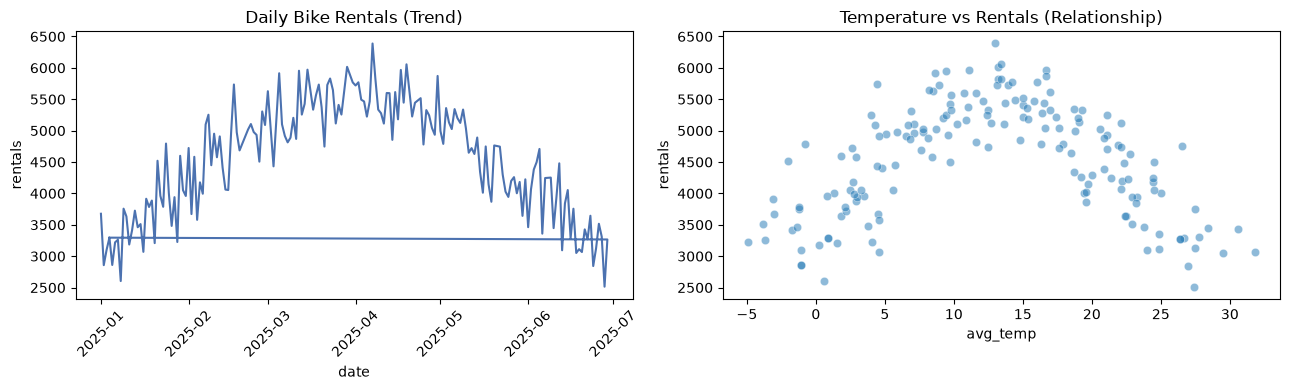

In [4]:
# 시나리오 3 — 시각화 (이상치 제거 후)
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()


## 4. 패턴 (시각화에서 읽은 것)

- 추이: 1월부터 대여량이 점차 증가하여 4월경 가장 많아졌고, 이후 다시 감소하는 계절성이 나타났다.
- 관계: 기온이 높아질수록 대여량이 증가하는 경향을 보였으며, 매우 높은 기온에서는 다시 감소하는 모습도 일부 나타났다.

## 5. 다음 분석 제안

- avg_temp의 이상치(250.0)는 현실적으로 발생하기 어려운 값이므로 제거한 뒤 분석하는 것이 적절하다.
- rentals의 결측치 8건은 평균값 대체 또는 삭제 등 적절한 방법으로 처리한 후 분석을 진행하는 것이 좋다.
- rainfall(강수량)이 대여량에 어떤 영향을 미치는지 추가 분석해 보면 의미 있는 결과를 얻을 수 있을 것 같다.